In [1]:
# ============================================
# CELL 1: IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# ============================================
# CELL 2: LOAD & UNDERSTAND DATA
# ============================================

df = pd.read_csv("throo_nyc_demand.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nData Types:")
display(df.dtypes)

print("\nStatistical Summary:")
display(df.describe().T)

Dataset Shape: (15000, 23)

First 5 rows:


,date,pickup_time,pickup_location,drop_location,distance,duration,ride_type,driver_rating,rider_rating,surge,payment_method,demand,fare,driver_id,driver_latitude,driver_longitude,driver_available,driver_status,request_latitude,request_longitude,pickup_wait_time,cancellation_flag,available_driver_count
0,2025-03-16,05:30:14,Downtown,Suburbs,31.66,98.0,Standard,4.7,4.7,1.0,Cash,Medium,71.99,D3982,40.79546,-74.04151,0,Busy,40.78502,-74.03952,38.5,0,13
1,2025-03-22,14:03:31,Downtown,Downtown,10.87,32.0,Standard,4.7,4.5,1.0,Credit Card,Medium,24.30,D6352,40.76902,-73.94095,0,Busy,40.77979,-73.94965,27.9,0,24
2,2025-03-16,08:16:28,Downtown,Downtown,18.20,55.0,Standard,4.6,4.9,1.0,Credit Card,Medium,41.05,D7170,40.75414,-73.99255,1,Available,40.76850,-74.00629,16.3,1,18
3,2025-03-17,19:37:14,Downtown,Suburbs,21.56,59.0,Standard,4.9,4.6,2.2,Credit Card,High,103.60,D6687,40.77960,-73.98989,1,Available,40.76076,-74.00841,20.4,0,2
4,2025-01-20,14:12:23,Suburbs,Downtown,12.87,30.0,Pool,4.6,4.9,1.0,Digital Wallet,Medium,18.76,D1080,40.93884,-73.86098,1,Available,40.93428,-73.89532,17.9,1,12



Data Types:


date                          str
pickup_time                   str
pickup_location               str
drop_location                 str
distance                  float64
duration                  float64
ride_type                     str
driver_rating             float64
rider_rating              float64
surge                     float64
payment_method                str
demand                        str
fare                      float64
driver_id                     str
driver_latitude           float64
driver_longitude          float64
driver_available            int64
driver_status                 str
request_latitude          float64
request_longitude         float64
pickup_wait_time          float64
cancellation_flag           int64
available_driver_count      int64
dtype: object


Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
distance,14574.0,19.402096,9.547012,1.20000,11.660000,20.08000,27.600000,35.00000
duration,14359.0,58.396058,25.601754,8.00000,38.000000,59.00000,77.000000,125.00000
driver_rating,14239.0,4.500934,0.291312,4.00000,4.200000,4.50000,4.800000,5.00000
rider_rating,15000.0,4.596767,0.234186,4.20000,4.400000,4.60000,4.800000,5.00000
surge,15000.0,1.286033,0.474549,1.00000,1.000000,1.00000,1.600000,2.50000
fare,15000.0,60.901245,45.553277,2.89000,30.000000,50.55000,76.110000,355.07000
driver_latitude,15000.0,40.794913,0.099149,40.58176,40.737248,40.76450,40.885867,41.11097
driver_longitude,15000.0,-73.938236,0.072763,-74.08319,-73.990052,-73.96361,-73.899655,-73.72269
driver_available,15000.0,0.758867,0.427785,0.00000,1.000000,1.00000,1.000000,1.00000
request_latitude,15000.0,40.795003,0.097686,40.60335,40.741127,40.76261,40.889268,41.09027


In [4]:
# ============================================
# CELL 3: DATA CLEANING
# ============================================

print("Missing Values:")
display(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Convert date
df["date"] = pd.to_datetime(df["date"])

# Combine date and pickup time
df["datetime"] = pd.to_datetime(
    df["date"].astype(str) + " " + df["pickup_time"].astype(str)
)

print("\nDataset after cleaning:", df.shape)

Missing Values:


distance         426
duration         641
driver_rating    761
dtype: int64


Duplicate Rows: 0

Dataset after cleaning: (15000, 24)


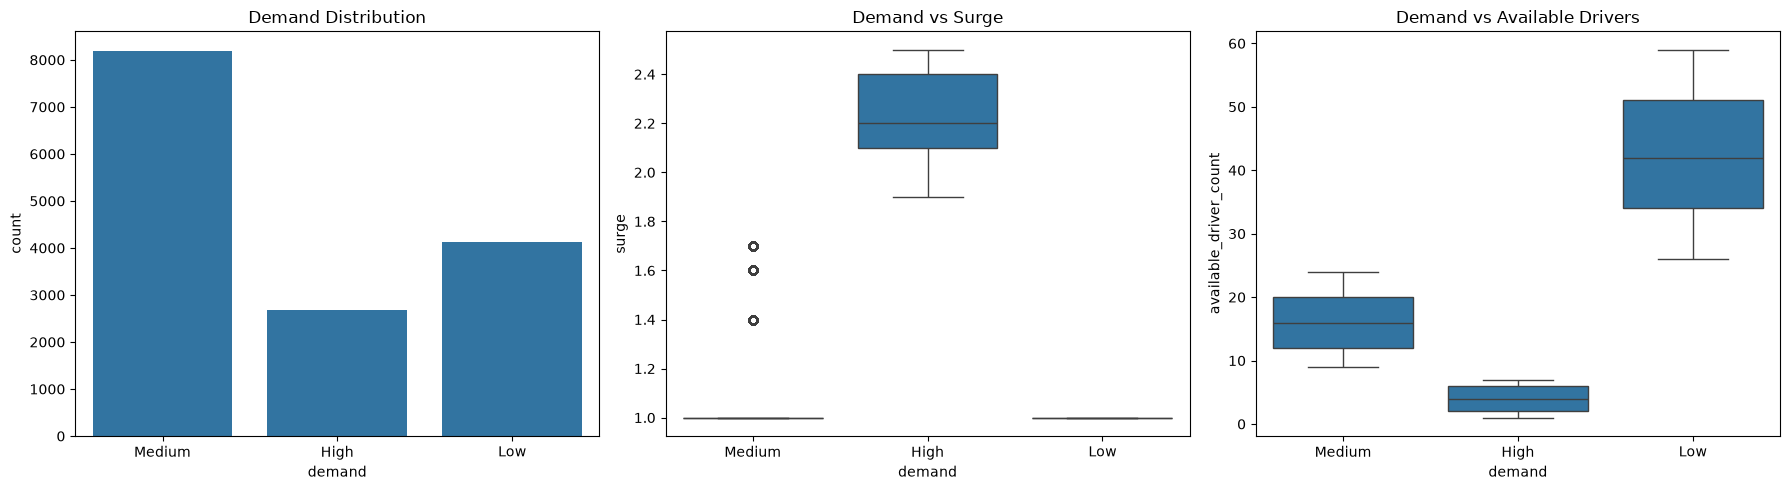

In [5]:
# ============================================
# CELL 4: EXPLORATORY DATA ANALYSIS
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Demand distribution
sns.countplot(data=df, x="demand", ax=axes[0])
axes[0].set_title("Demand Distribution")

# Demand vs Surge
sns.boxplot(
    data=df,
    x="demand",
    y="surge",
    ax=axes[1]
)
axes[1].set_title("Demand vs Surge")

# Demand vs Available Drivers
sns.boxplot(
    data=df,
    x="demand",
    y="available_driver_count",
    ax=axes[2]
)
axes[2].set_title("Demand vs Available Drivers")

plt.tight_layout()
plt.show()

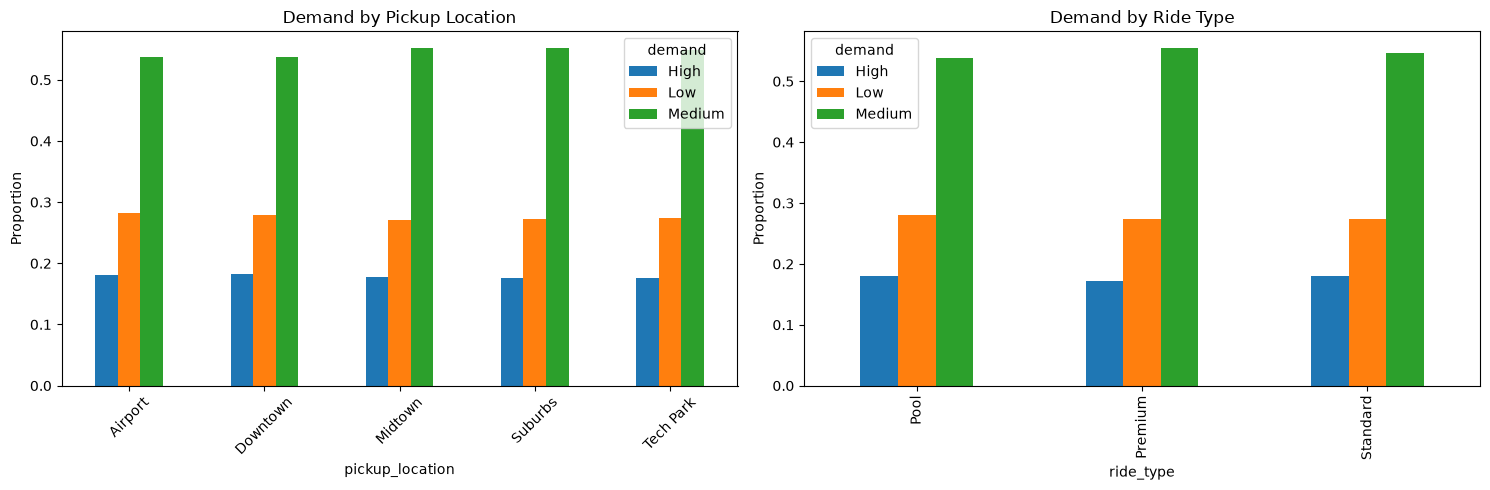

In [6]:
# ============================================
# CELL 5: CATEGORICAL EDA
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pickup location vs demand
location_demand = pd.crosstab(
    df["pickup_location"],
    df["demand"],
    normalize="index"
)

location_demand.plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Demand by Pickup Location")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis="x", rotation=45)

# Ride type vs demand
ride_demand = pd.crosstab(
    df["ride_type"],
    df["demand"],
    normalize="index"
)

ride_demand.plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Demand by Ride Type")
axes[1].set_ylabel("Proportion")

plt.tight_layout()
plt.show()

In [7]:
# ============================================
# CELL 6: FEATURE ENGINEERING
# ============================================

# Extract time features
df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day
df["day_of_week"] = df["datetime"].dt.dayofweek
df["month"] = df["datetime"].dt.month
df["week_of_year"] = df["datetime"].dt.isocalendar().week.astype(int)

# Weekend
df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

# Rush hour
df["rush_hour"] = (
    df["hour"].isin([7, 8, 9, 17, 18, 19, 20])
).astype(int)

# Cyclical time features
df["hour_sin"] = np.sin(
    2 * np.pi * df["hour"] / 24
)

df["hour_cos"] = np.cos(
    2 * np.pi * df["hour"] / 24
)

df["dow_sin"] = np.sin(
    2 * np.pi * df["day_of_week"] / 7
)

df["dow_cos"] = np.cos(
    2 * np.pi * df["day_of_week"] / 7
)

print("Feature engineering completed!")

display(
    df[
        [
            "datetime",
            "hour",
            "day_of_week",
            "month",
            "is_weekend",
            "rush_hour"
        ]
    ].head()
)

Feature engineering completed!


,datetime,hour,day_of_week,month,is_weekend,rush_hour
0,2025-03-16 05:30:14,5,6,3,1,0
1,2025-03-22 14:03:31,14,5,3,1,0
2,2025-03-16 08:16:28,8,6,3,1,1
3,2025-03-17 19:37:14,19,0,3,0,1
4,2025-01-20 14:12:23,14,0,1,0,0


In [8]:
# ============================================
# CELL 7: PREPARE FEATURES & TARGET
# ============================================

# Target
y = df["demand"]

# Remove target and columns that should not be predictors
columns_to_drop = [
    "demand",
    "datetime",
    "date",
    "pickup_time",
    "driver_id",

    # Potential data leakage
    "duration",
    "fare",
    "rider_rating",
    "pickup_wait_time",
    "cancellation_flag"
]

X = df.drop(
    columns=columns_to_drop
)

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:")
print(y.value_counts())

Features shape: (15000, 25)
Target shape: (15000,)

Target classes:
demand
Medium    8197
Low       4128
High      2675
Name: count, dtype: int64


In [9]:
# ============================================
# CELL 8: TIME-BASED TRAIN/TEST SPLIT
# ============================================

df = df.sort_values("datetime").reset_index(drop=True)

split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

X_train = train_df.drop(
    columns=columns_to_drop
)

y_train = train_df["demand"]

X_test = test_df.drop(
    columns=columns_to_drop
)

y_test = test_df["demand"]

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

print("\nTraining period:")
print(train_df["datetime"].min(), "to", train_df["datetime"].max())

print("\nTesting period:")
print(test_df["datetime"].min(), "to", test_df["datetime"].max())

Training data: (12000, 25)
Testing data : (3000, 25)

Training period:
2025-01-01 00:00:37 to 2025-03-13 02:28:46

Testing period:
2025-03-13 02:42:18 to 2025-03-30 23:56:17


In [10]:
# ============================================
# CELL 9: PREPROCESSING
# ============================================

categorical_features = [
    "pickup_location",
    "drop_location",
    "ride_type",
    "payment_method",
    "driver_status"
]

numeric_features = [
    "distance",
    "driver_rating",
    "surge",
    "driver_latitude",
    "driver_longitude",
    "driver_available",
    "request_latitude",
    "request_longitude",
    "available_driver_count",
    "hour",
    "day",
    "day_of_week",
    "month",
    "week_of_year",
    "is_weekend",
    "rush_hour",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos"
]

# Numerical preprocessing
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

# Combine both
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

print("Preprocessing pipeline created!")

Preprocessing pipeline created!


In [11]:
# ============================================
# CELL 10: MODEL TRAINING
# ============================================

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

trained_models = {}
predictions = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    pred = pipeline.predict(X_test)

    trained_models[name] = pipeline
    predictions[name] = pred

    print(name, "trained successfully!")

print("\nAll models trained!")

Logistic Regression trained successfully!
Random Forest trained successfully!
Extra Trees trained successfully!

All models trained!


In [13]:
# ============================================
# CELL 11: MODEL EVALUATION & COMPARISON
# ============================================

results = []

for name, pred in predictions.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            pred
        ),
        "Precision": precision_score(
            y_test,
            pred,
            average="weighted",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pred,
            average="weighted",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            pred,
            average="weighted",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "F1 Score",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.000,1.000000,1.000,1.000000
1,Random Forest,1.000,1.000000,1.000,1.000000
2,Extra Trees,0.983,0.983499,0.983,0.982843


FINAL MODEL: Random Forest

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       522
         Low       1.00      1.00      1.00       791
      Medium       1.00      1.00      1.00      1687

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



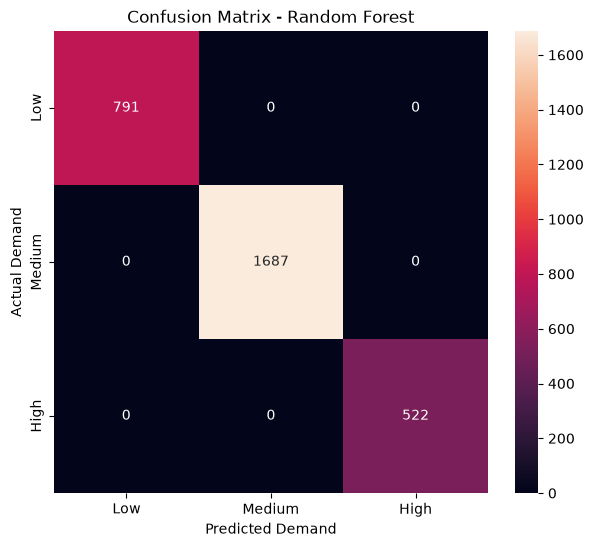

In [14]:
# ============================================
# CELL 12: FINAL MODEL EVALUATION
# ============================================

final_model_name = "Random Forest"

final_model = trained_models[
    final_model_name
]

final_predictions = predictions[
    final_model_name
]

print("FINAL MODEL:", final_model_name)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        final_predictions,
        zero_division=0
    )
)

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    final_predictions,
    labels=["Low", "Medium", "High"]
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"]
)

plt.xlabel("Predicted Demand")
plt.ylabel("Actual Demand")
plt.title(
    f"Confusion Matrix - {final_model_name}"
)

plt.show()

,Feature,Importance
8,numeric__available_driver_count,0.613517
2,numeric__surge,0.313847
0,numeric__distance,0.006662
7,numeric__request_longitude,0.006612
6,numeric__request_latitude,0.006475
3,numeric__driver_latitude,0.006474
4,numeric__driver_longitude,0.006461
10,numeric__day,0.004212
1,numeric__driver_rating,0.003802
9,numeric__hour,0.003539


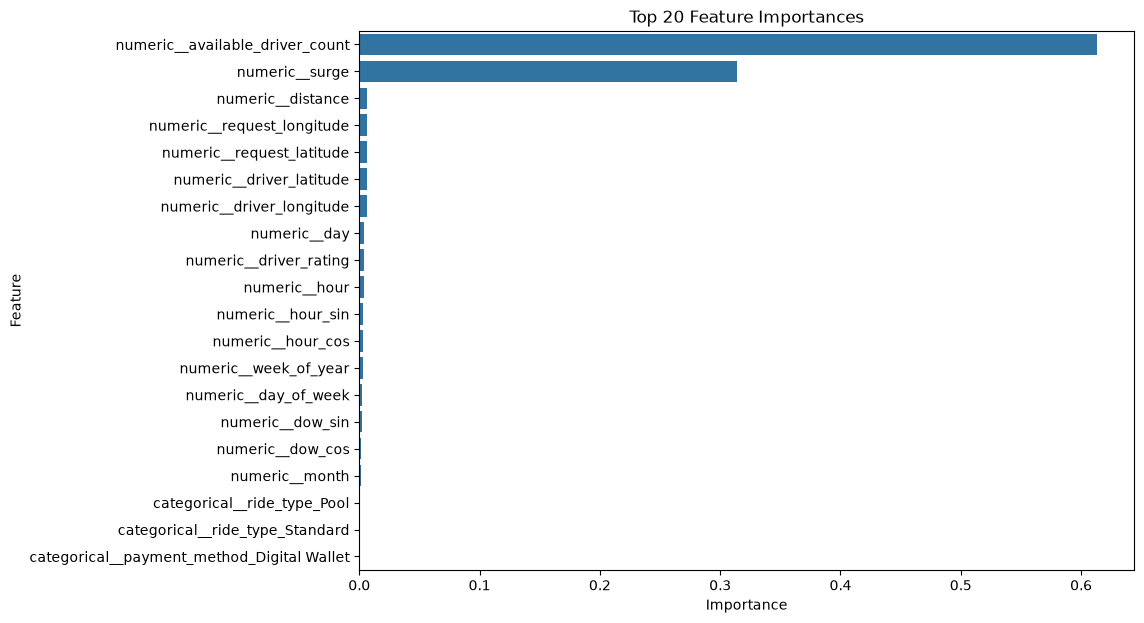

In [15]:
# ============================================
# OPTIONAL CELL 13: FEATURE IMPORTANCE
# ============================================

model = final_model.named_steps["model"]
preprocessor_fitted = final_model.named_steps["preprocessor"]

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

importance = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(20)
)

display(importance_df)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances")

plt.show()

In [16]:
# ============================================
# OPTIONAL CELL 14: SAVE MODEL
# ============================================

joblib.dump(
    final_model,
    "nyc_demand_classification_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [17]:
# ============================================
# SEE FINAL MODEL PREDICTION
# ============================================

sample = X_test.iloc[[0]]

actual = y_test.iloc[0]
predicted = final_model.predict(sample)[0]

print("Actual Demand    :", actual)
print("Predicted Demand :", predicted)

Actual Demand    : Low
Predicted Demand : Low


In [18]:
# ============================================
# PREDICTION PROBABILITIES
# ============================================

probabilities = final_model.predict_proba(sample)

probability_df = pd.DataFrame(
    probabilities,
    columns=final_model.classes_
)

display(probability_df)

,High,Low,Medium
0,0.006667,0.926667,0.066667
